# Метод главных компонент
**Метод главных компонент** (principal component analysis, PCA) используется для
понижения размерности данных.
## Понижение размерности как проекция
Возьмем набор данных, состоящий из двух признаков $x_1$ и $x_2.$ Поставим
задачу сократить эти данные до одного измерения.

Пусть для начала данные обладают большой дисперсией только по измерению
$x_2.$

![](https://drive.google.com/uc?export=view&id=1_VfT8TnICTz4MIXcGSXklBnbtjyeNz5m)

В этом случае мы можем смело отбросить признак $x_1,$ поскольку он не обладает
существенной дисперсией и несет в себе мало информации. На практике же данные
чаще обладают изменчивостью по более чем одному измерению и просто отбросить
одно из измерений было бы неразумно.

![](https://drive.google.com/uc?export=view&id=1aJuxd-BdrADBD4bk18-g1rdBUFmG3m3D)

Представляется более логичным найти такое (отличное от изначальных) измерение
$x’,$ проекция наблюдений на которое, будет давать наибольшую дисперсию
данных.

![](https://drive.google.com/uc?export=view&id=1iSBE5S6VNPJAyHPr5Of_4wmWEyhrlwba)

Заметим, что выше мы стандартизировали данные

$$ \mathbf x_{std} = \frac{\mathbf x-\mu}{\sigma}, $$

то есть привели их к нулевому среднему (так вектор проекции $x’$ будет проходить
через начало координат) и СКО равному единице (это важно, потому что мы хотели
бы сравнивать изменчивость данных по каждому из изначальных измерений).

Обратим внимание, что задача нахождения оси проекции с наибольшей дисперсией
данных аналогична задаче нахождения оси, минимизирующей ортогональные
расстояния к проекциям наблюдений.

Это расстояние также называют ошибкой проектирования или
**reconstruction error**, потому что если мы захотим восстановить исходные
данные, именно это расстояние необходимо будет компенсировать.

В самом деле, рассмотрим единственное наблюдение $\mathbf x_i$ и возможную
ось проекции $x’.$

![](https://drive.google.com/uc?export=view&id=1EBWQkb04BJ43Z-Gtg0QYKGfujzDMG17W)

В силу того что ось проекции обязательно проходит через начало координат,
расстояние $a$ (гипотенуза прямоугольного треугольника) фиксировано, и задача
максимизации катета $b$ аналогична задаче минимизации катета $c.$

Формализуем сказанное выше.


## Решение через ковариационную матрицу
Пусть $x_i’$ скалярная проекция одного из наблюдений $\mathbf x_i$ на ось $x’$ и
вектор $\mathbf w$ — единичный вектор в направлении $x’.$

![](https://drive.google.com/uc?export=view&id=1OaGlZ4gthBAeNvJ0CMmDzPdYuUSCpIz_)

Другими словами,

$$ x_i’ = \frac{\mathbf w^\top \mathbf x_i}{|| \mathbf w ||} $$

Поскольку $|| \mathbf w ||^2 = 1,$ то

$$ x_i’ = \mathbf w^\top \mathbf x_i $$

Если $\boldsymbol \mu$ — вектор средних значений, то скалярную проекцию
среднего (среднее всех проекций) можно выразить через

$$ \bar{x}’ = \mathbf w^\top \boldsymbol \mu $$

Не будем забывать, что после стандартизации $\bar{x}’ = \mathbf w^\top \mathbf 0 =
0.$ Тогда дисперсию проекций $x_i’$ на $x’$ можно записать как

$$ \mathbb{V} \left[ \{ x_i’\}^N_{i=1} \right] = \mathbb{V} \left[ \{ \mathbf v^\top
\mathbf x_i \}^N_{i=1} \right] = \frac{1}{N} \sum^{N}_{i=1} (\mathbf w^\top \mathbf
x_i-\mathbf w^\top \boldsymbol \mu)^2 $$

Поскольку $\mathbf w^\top \boldsymbol \mu = 0,$

$$ \mathbb{V} \left[ \{ \mathbf w^\top \mathbf x_i \}^N_{i=1} \right] = \frac{1}{N}
\sum^{N}_{i=1} (\mathbf w^\top \mathbf x_i)^2 $$

Таким образом, задача сводится к нахождению вектора $\mathbf w^*,$ такого что

$$ \begin{split} \begin{align} \mathbf w^* &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmax}} \frac{1}{N} \sum^N_{i=1} (\mathbf w^\top \mathbf x_i)^2
\end{align} \end{split} $$

Вектор $\mathbf w^*$ при этом называется первой главной компонентой (first
principal component,
PC1). Еще раз заметим, что эта задача аналогична задаче
минимизации ортогональных расстояний к проекциям $x_i’$

$$ \begin{split} \begin{align} \mathbf w^* &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmin}} \frac{1}{N} \sum^N_{i=1} || \mathbf x_i-(\mathbf w^\top
\mathbf x_i) \mathbf w ||^2 \\ &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmin}} \frac{1}{N} \sum^N_{i=1} || \mathbf x_i ||^2-(\mathbf w^\top
\mathbf x_i)^2, \end{align} \end{split} $$

в силу того, что $\mathbf w^\top \mathbf w = || \mathbf w ||^2 = 1.$ Перепишем задачу
максимизации дисперсии с помощью матричной формы записи.

$$ \begin{split} \begin{align} \mathbf w^* &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmax}} \frac{1}{N} \sum^N_{i=1} (\mathbf w^\top \mathbf x_i)^2 \\
&= \underset{\mathbf w : ||\mathbf w||^2=1}{\operatorname{argmax}} \frac{1}{N}
\lbrace || \mathbf X \mathbf w ||^2 \rbrace \\ &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmax}} \lbrace \mathbf w^\top \mathbf \Sigma \mathbf w \rbrace,
\end{align} \end{split} $$

где $\mathbf \Sigma = N^{-1} \mathbf X^\top \mathbf X = N^{-1} \sum_{i=1}^N
\mathbf x_i \mathbf x_i^\top$ — ковариационная матрица стандартизированной
матрицы признаков $\mathbf X.$ При этом решение задачи

$$ \begin{split} \begin{align} \mathbf w^* &= \underset{\mathbf w : ||\mathbf w||^2=1}
{\operatorname{argmax}} \lbrace \mathbf w^\top \mathbf \Sigma \mathbf w \rbrace
\end{align} \end{split} $$

аналогично задаче

$$ \begin{split} \begin{align} \mathbf w^* &= {\operatorname{argmax}}
\begin{Bmatrix} \frac{ \mathbf w^\top \mathbf \Sigma \mathbf w }{\mathbf w^\top
\mathbf w} \end{Bmatrix}, \end{align} \end{split} $$

где $ \frac{ \mathbf w^\top \mathbf \Sigma \mathbf w }{\mathbf w^\top \mathbf w} $ — **отношение Рэлея** (Rayleigh quotient). Применив метод множителей Лагранжа,
получим

$$ \mathcal{L} (\mathbf w, \lambda) = \mathbf w^\top \mathbf \Sigma \mathbf w-
\lambda (\mathbf w^\top \mathbf w-1) $$

Дифференцируя по $\mathbf w,$ получим

$$ \begin{split} \begin{array}{rr} \frac{\partial \mathcal{L}}{\partial \mathbf w} &=&
2 \mathbf \Sigma \mathbf w-\lambda 2 \mathbf w &=& 0 \\ & & \mathbf \Sigma \mathbf
w &=& \lambda \mathbf w \end{array} \end{split} $$

Таким образом, задача сводится к нахождению собственных значений $\lambda$ и
соответствующих им собственных векторов $\mathbf w$ матрицы $\mathbf \Sigma =
N^{-1} \mathbf X^\top \mathbf X.$

Взяв первые $m$ компонент $\mathbf w_j,$ сформируем матрицу $\mathbf W_{d
\times m},$ где $d$ — количество изначальных измерений. При умножении на
матрицу данных $\mathbf X_{n \times d},$ мы получим их проекцию $\mathbf Z_{n
\times m}$ на выбранные $m$ главных компонент.

$$ \mathbf Z = \mathbf X \cdot \mathbf W $$

В частности, для $m=2$ получим,

$$ \mathbf Z = \mathbf X \cdot \mathbf W = \begin{pmatrix} x_{11} & x_{12} & \dots
& x_{1d} \\ x_{21} & x_{22} & \dots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{nd} \end{pmatrix} \cdot \underbrace{ \begin{pmatrix}
w_1^{(1)} & w_1^{(2)} \\ w_2^{(1)} & w_2^{(2)} \\ \vdots & \vdots \\ w_d^{(1)} &
w_d^{(2)} \end{pmatrix} }_{m=2} = \begin{pmatrix} \vert & \vert \\ \mathbf {PC1} &
\mathbf {PC2} \\ \vert & \vert \end{pmatrix} $$

Заметим, что результатом $ \mathbf Z \cdot \mathbf W^\top + \boldsymbol \mu $ будет
(приближенно) восстановленная (reconstructed) матрица $\mathbf X.$ При этом, что
логично, чем больше компонент было использовано для проекции, тем выше будет
качество восстановления данных.

Кроме этого, скажем, что собственные значения $\lambda_j$ показывают, какую
часть общей дисперсии объясняет каждый из собственных векторов. В частности,
долю **объясненной дисперсии** (explained variance) первой компоненты можно
найти по формуле

$$ \frac{\lambda_1}{\lambda_1 + \lambda_2 + \ldots + \lambda_d} $$

Добавим, что с точки зрения **спектрального разложения** (spectral
decomposition), симметричную квадратную ковариационную матрицу $\mathbf
\Sigma_{d \times d}$ можно разложить на

$$ \mathbf \Sigma = \mathbf W \mathbf \Lambda \mathbf W^\top, $$

где столбцы матрицы $\mathbf W_{d \times d}$ являются собственными векторами
$\mathbf \Sigma,$ а диагональные элементы $\mathbf \Lambda$ соответствующими
собственными значениями.

Умножив на $\mathbf W,$ получим

$$ \mathbf \Sigma \mathbf W = \mathbf W \mathbf \Lambda \mathbf W^\top \mathbf W
= \mathbf W \mathbf \Lambda, $$

что, если положить $ \mathbf w_i $ как $i$-ый столбец $\mathbf W$ и $\lambda_i =
\mathbf \Lambda_{ii},$ соответствует решению

$$ \mathbf \Sigma \mathbf w_i = \lambda_i \mathbf w_i. $$

## Решение через сингулярное разложение
Одновременно для матрицы данных $\mathbf X_{n \times d}$ можно построить
**сингулярное разложение** (singular value decomposition, SVD). В частности,

$$ \mathbf X = \mathbf U \mathbf \Gamma \mathbf V^\top, $$

где $\mathbf U_{n \times n}$ — матрица левых сингулярных векторов, $\mathbf
\Gamma_{n \times d}$ — матрица, элементы главной диагонали которой
называются сингулярными числами и $\mathbf V_{d \times d}$ — матрица правых
сингулярных векторов.

Интересно, что

$$ \begin{split} \begin{array}{ll} \mathbf X &= \mathbf U \mathbf \Gamma \mathbf
V^\top \\ \mathbf X^\top &= (\mathbf U \mathbf \Gamma \mathbf V^\top)^\top = \mathbf
V \mathbf \Gamma \mathbf U^\top \\ \mathbf X^\top \mathbf X &= \mathbf V \mathbf
\Gamma (\mathbf U^\top \mathbf U) \mathbf \Gamma \mathbf V^\top \\ \mathbf X^\top
\mathbf X &= \mathbf V \mathbf \Gamma^2 \mathbf V^\top \end{array} \end{split} $$

Другими словами, матрица $\mathbf W$ спектрального разложения $\mathbf \Sigma
= N^{-1} \mathbf X^\top \mathbf X$ соответствует матрице $\mathbf V^\top$
сингулярного разложения $\mathbf X.$ При этом $N^{-1} \mathbf \Gamma^2 =
\mathbf \Lambda.$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

**Код на Питоне**
## Класс PCA
Создадим класс PCA.

In [2]:
class PCA:

  def __init__(self, n_components, solver='covariance'):
    self.n_components = n_components
    self.mean = None
    self.explained_variance = None
    self.solver = solver

  def fit(self, X):

    self.mean = np.mean(X, axis=0)

    if self.solver == 'covariance':
      covariances = (X - self.mean).T.dot((X - self.mean)) / (X.shape[0]-1)
      eigenvalues, eigenvectors = np.linalg.eig(covariances)

      idxs = np.argsort(eigenvalues)[::-1]
      eigenvalues = eigenvalues[idxs]
      eigenvectors = eigenvectors[idxs].T

    elif self.solver == 'svd':
      X = X - self.mean
      U, S, Vt = np.linalg.svd(X)

      eigenvalues, eigenvectors = S**2 / (X.shape[0]-1), Vt

    self.W = eigenvectors[:self.n_components]
    self.explained_variance = np.sum(eigenvalues[:self.n_components]) / np.sum(eigenvalues)

    return self

  def transform(self, X):

    X -= self.mean
    return np.dot(X, self.W.T)

  def transform_inverse(self, X):

    return np.dot(X, self.W) + self.mean

Понизим размерность датасета Iris с четырех до двух измерений.

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

Применим как метод ковариационной матрицы, так и SVD, посмотрим на величину
объясненной дисперсии и сравним получившиеся датасеты.

In [4]:
pca = PCA(n_components=2, solver='covariance')
X_pca = pca.fit(X_std).transform(X_std)
print(X_pca.shape, pca.explained_variance)

(150, 2) 0.9581320720000165


In [5]:
pca_svd = PCA(n_components=2, solver='svd')
X_pca_svd = pca_svd.fit(X_std).transform(X_std)
print(X_pca_svd.shape, pca_svd.explained_variance)

(150, 2) 0.9581320720000165


In [6]:
np.allclose(X_pca, X_pca_svd)

True

Посмотрим на результат на графике.

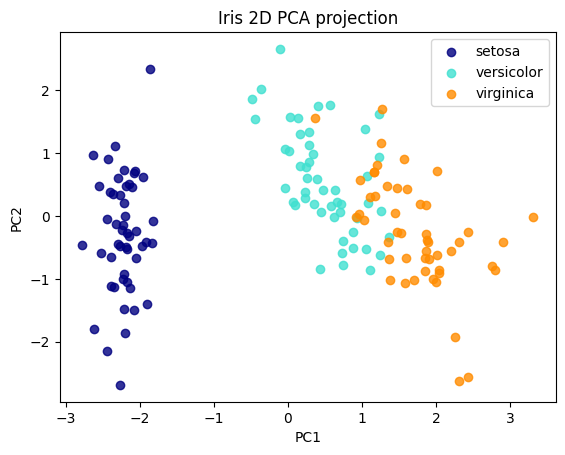

In [7]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']

for color, i, class_name in zip(colors, [0, 1, 2], iris.target_names):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=0.8, label=class_name)
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title('Iris 2D PCA projection')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

Для того чтобы оценить, на какое количество компонент проецировать исходные
данные, можно использовать метод локтя.

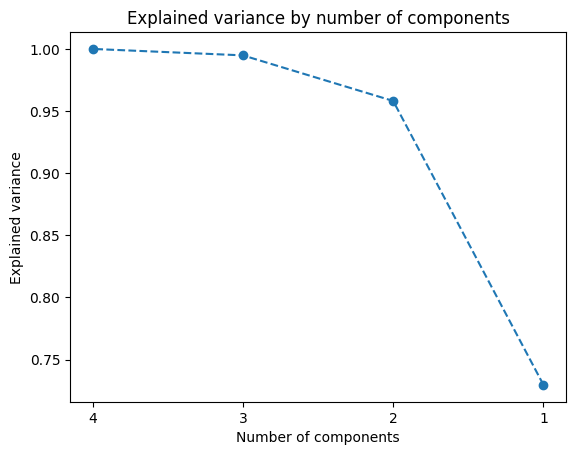

In [8]:
components_range = range(1,5)
explained_vars = [PCA(n_components=i).fit(X_std).explained_variance for i in components_range]
plt.plot(components_range, explained_vars, '--o')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.xticks(components_range)
plt.gca().invert_xaxis()
plt.title('Explained variance by number of components')
plt.show()

Одна компонента объясняет менее 0,75 дисперсии, в то время как две компоненты
уже более 0,95.

Если использовать не все компоненты проекции, то полностью восстановить
данные не получится.

In [9]:
X_reconstructed = pca.transform_inverse(X_pca)
X_reconstructed[0], X_std[0]

(array([-0.99888895,  1.05319838, -1.30270654, -1.24709825]),
 array([-0.90068117,  1.01900435, -1.34022653, -1.3154443 ]))

In [10]:
# данные совпадают при достаточно большом допустимом отклонении
np.allclose(X_reconstructed, X_std, atol=0.8)

True

## Метод собственных лиц

### Описание метода

M. Turk и A. Pentland (1991) предложили⧉ использовать метод главных компонент
для распознавания лиц. Основная идея заключается в том, чтобы взять набор
изображений лиц

$$\Gamma_1, \Gamma_2, \ldots, \Gamma_n = \mathbf \Gamma_{n \times d},$$

где $n$ — количество изображений, а $d$ — количество измерений (пикселей) в
изображении $\Gamma_i.$ Найти среднее лицо (mean face), т.е. вектор

$$ \boldsymbol \psi_{d \times 1} = \frac{1}{N} \sum^N_{i=1} \Gamma_i $$

и центрировать данные $ \mathbf \Phi_{n \times d} = \mathbf \Gamma-\boldsymbol
\psi. $ После этого применить метод главных компонент и найти собственные
векторы матрицы $\mathbf \Phi.$

Взяв первые $m$ компонент, получим матрицу собственных векторов (eigenvectors)
или, в контексте задачи, собственных лиц (eigenfaces) $ \mathbf W_{d \times m}.
$ Каждая из $m$ координат проекции

$$ \mathbf \Omega_{n \times m} = \mathbf \Phi_{n \times d} \cdot \mathbf W_{d \times
m} $$

т.е. $\mathbf \Omega^\top = [\omega_1, \omega_2, \ldots, \omega_m ] $ являются
коэффициентами (весами) линейных комбинаций конкретного лица в собственном
базисе.

Для нового лица $ \Phi’ = \Gamma’-\boldsymbol \psi$ мы также можем рассчитать
проекцию $\omega’$ на собственный базис

$$ \omega’ = \Phi’ \cdot \mathbf W.$$

После этого достаточно рассчитать евклидово расстояние до каждого из известных
векторов $\mathbf \Omega^\top = [\omega_1, \omega_2, \ldots, \omega_m ] $

$$ \epsilon^2_{n \times 1} = || (\mathbf \Omega-\omega’) ||^2 $$

и выбрать то известное лицо, расстояние до которого минимально

$$ \underset{n}{\operatorname{argmin}} \{ \epsilon^2_{n \times 1} \}. $$

***Примечание.*** В данных с высокой размерностью, в которых количество признаков
существенно больше количества наблюдений, $ d >> n, $ ковариационную матрицу
$N^{-1} (\mathbf X^\top \mathbf X)_{d \times d}$ удобнее рассчитать через $N^{-1}
(\mathbf X \mathbf X^\top)_{n \times n}.$

В частности,

$$ \frac{1}{N} \mathbf X^\top \mathbf X \mathbf w = \lambda \mathbf w $$

$$ \frac{1}{N} \mathbf X \mathbf X^\top (\mathbf X \mathbf w) = \lambda (\mathbf X
\mathbf w) $$

Таким образом, $ \mathbf w’ = \mathbf X \mathbf w $ являются собственными
векторами $\mathbf X \mathbf X^\top,$ и для того чтобы найти собственные векторы
$\mathbf X^\top \mathbf X$ достаточно умножить $ \mathbf w’ $ на $\mathbf X^\top.$

При этом собственные значения $\mathbf X \mathbf X^\top$ и $\mathbf X^\top
\mathbf X$ совпадают. Помимо этого, поскольку $\mathbf w$ не обязательно
нормализованы, необходимо привести их к единичной норме

$$ \mathbf w = \frac{\mathbf w}{|| \mathbf w ||}. $$


**Алгоритм на Питоне**
### Подготовка данных

Возьмем датасет Olivetti Faces, в котором собраны 400 фотографий лиц 40
различных людей по 10 изображений для каждого человека.

In [11]:
from sklearn.datasets import fetch_olivetti_faces
olivetti_faces = fetch_olivetti_faces()
X, y, images = olivetti_faces.data, olivetti_faces.target, olivetti_faces.images
X.shape, y.shape, images.shape

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


((400, 4096), (400,), (400, 64, 64))

Посмотрим на лицо каждого из 40 человек.

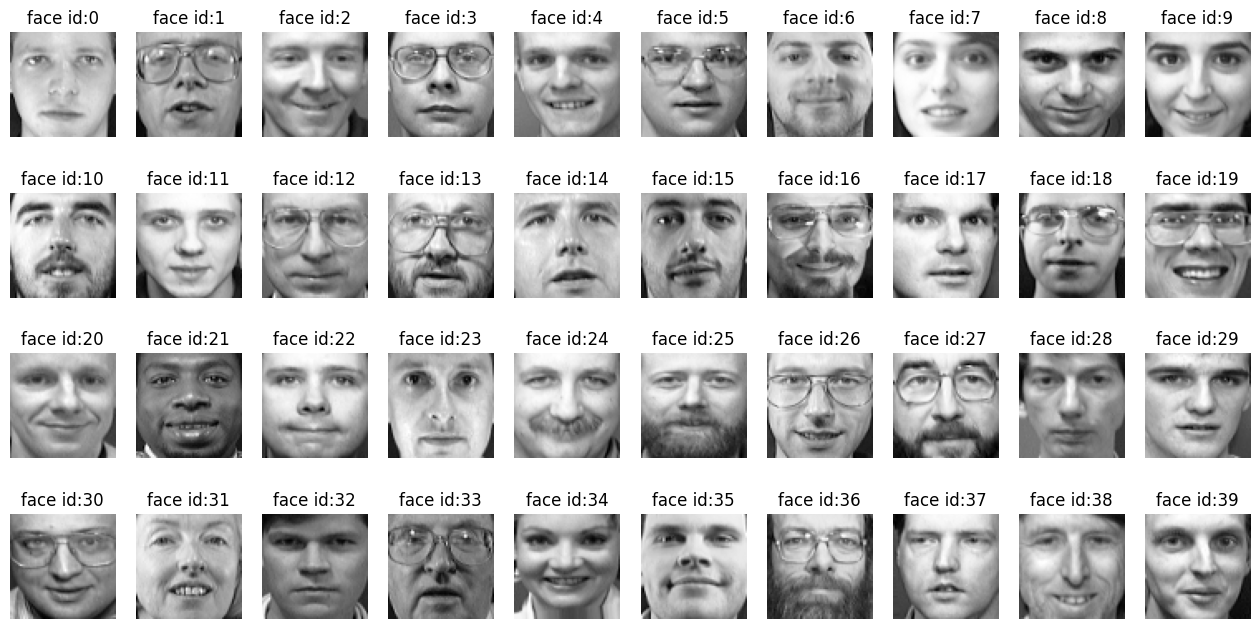

In [12]:
fig, ax=plt.subplots(4, 10, figsize=(16, 8))
ax=ax.flatten()

for unique_id in np.unique(y):
  image_index=unique_id*10
  ax[unique_id].imshow(images[image_index], cmap='gray')
  ax[unique_id].axis('off')
  ax[unique_id].set_title(f'face id:{unique_id}')

plt.show()

Выведем все десять фотографий первых трех людей.

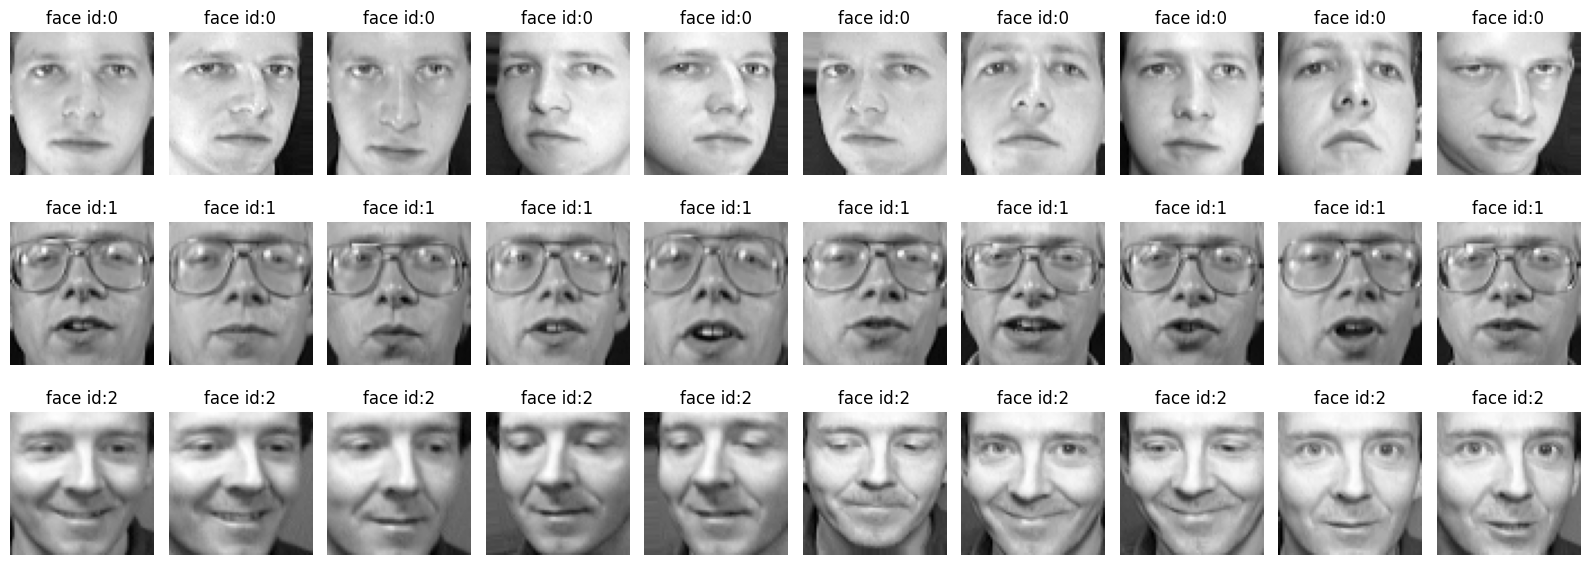

In [13]:
rows, cols = 3, 10
fig, ax=plt.subplots(rows, cols, figsize=(16,6))

for i in range(rows):
  for j in range(cols):
    image_index=i*10 + j
    ax[i,j].imshow(images[image_index], cmap='gray')
    ax[i,j].axis('off')
    ax[i,j].set_title(f'face id:{i}')

plt.tight_layout()
plt.show()

Поставим перед алгоритмом две задачи:
1. распознать лицо человека, чьи фотогорафии содежатся в обучающей выборке;
а также
2. попробовать найти лицо человека, фотографий которого в выборке нет.

Для этого разделим данные таким образом, чтобы последняя (десятая) фотография
человека с id 38 и все десять изображений человека с id 39 оказались в обучающей
выборке.

Другими словами, поместим первые 389 изображений в обучающую выборку, а
оставшиеся 11 в тестовую.

In [14]:
X_train, y_train, images_train = X[:389], y[:389], images[:389]
X_train.shape, y_train.shape, images_train.shape

((389, 4096), (389,), (389, 64, 64))

In [15]:
X_test, y_test, images_test = X[-11:], y[-11:], images[-11:]
X_test.shape, y_test.shape, images_test.shape

((11, 4096), (11,), (11, 64, 64))

In [16]:
np.unique(y_test, return_counts=True)

(array([38, 39]), array([ 1, 10]))

Посмотрим на фотографию человека, присутствующего в обучающей выборке (intrain-
sample), и человека, не содержащегося в ней (out-of-train-sample) лиц.

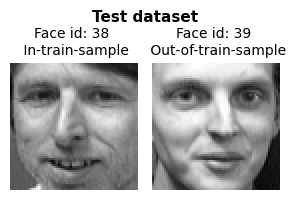

In [17]:
fig = plt.figure(figsize = (3,2))
fig.suptitle('Test dataset', size=11, weight='bold')
ax1 = fig.add_subplot(121)
ax1.set_title(f'Face id: {y_test[0]} \n In-train-sample', {'fontsize' : 10})
ax1.imshow(images_test[0], cmap='gray')
ax1.axis('off')
ax2 = fig.add_subplot(122)
ax2.set_title(f'Face id: {y_test[1]} \n Out-of-train-sample', {'fontsize' : 10})
ax2.imshow(images_test[1], cmap='gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [18]:
# также сохраним в переменную размерность изображения
faceshape = images_train[0].shape
faceshape

(64, 64)

### Нахождение собственных лиц
Вначале вычислим «среднее лицо».

In [19]:
mean = np.mean(X_train, axis=0)
mean.shape

(4096,)

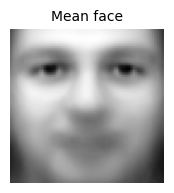

In [20]:
plt.figure(figsize=(2,2))
plt.imshow(mean.reshape(faceshape), cmap='gray')
plt.title('Mean face', size=10)
plt.axis('off')
plt.show()

Теперь, поскольку $ d >> n, $ найдем собственные векторы $\mathbf X \mathbf
X^\top,$ а затем преобразуем в собственные векторы $\mathbf X^\top \mathbf X,$
умножив на $\mathbf X^\top.$

In [21]:
X_centered = X_train - mean
covariance_matrix = (X_centered @ X_centered.T) / (X_centered.shape[0]-1)
covariance_matrix.shape

(389, 389)

In [22]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
idxs = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idxs]
eigenvectors = eigenvectors[:,idxs]
eigenvectors_converted = X_centered.T @ eigenvectors
eigenvectors_converted.shape

(4096, 389)

Не забудем нормализовать собственные векторы $\mathbf X^\top \mathbf X.$

In [23]:
eigenvectors_converted = eigenvectors_converted.T / np.sqrt((eigenvectors_converted.T ** 2).sum(axis=1, keepdims=True))
eigenvectors_converted.shape

(389, 4096)

### Объсненная дисперсия
Найдем количество компонент, которые объясняют не менее 90% дисперсии.

In [24]:
total = sum(eigenvalues)

# найдем долю дисперсии, объясненную каждым из собственных значений
explained_variance = [(i / total) * 100 for i in eigenvalues]
explained_variance = np.round(explained_variance, 2)

# вычислим кумулятивную дисперсию первых n собственных значений
cumulative_explained_variance = np.cumsum(explained_variance)

# найдем количество компонент, которые объясняют не менее 90% дисперсии
variance_threshold = 90
n_components = np.argwhere(cumulative_explained_variance >=
                           variance_threshold).min()+1
print(n_components)

66


Посмотрим на результат на графике.

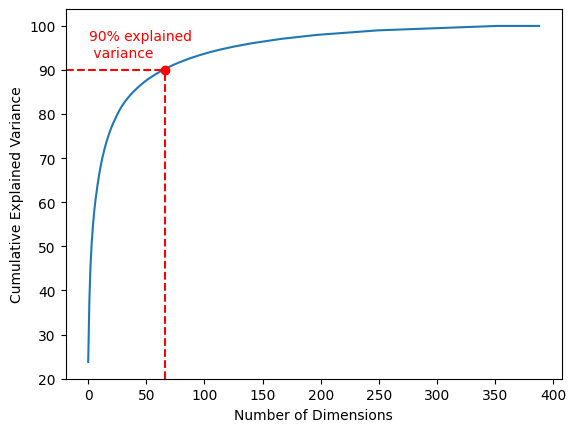

In [25]:
plt.plot(cumulative_explained_variance)
plt.plot(n_components, variance_threshold, 'o', color='r')
plt.axhline(y=variance_threshold, xmax=0.2, linestyle='--', color='r')
plt.axvline(x=n_components, ymax=0.84, linestyle='--', color='r')
plt.text(0.5, 93, '90% explained \n variance', color='red')
plt.xlabel('Number of Dimensions')
plt.ylabel('Cumulative Explained Variance')
plt.show()

Оставленные компоненты и будут собственными лицами (eigenfaces) $\mathbf W.$

In [26]:
eigenfaces = eigenvectors_converted[:n_components]
eigenfaces.shape

(66, 4096)

Посмотрим на первые девять собственных лиц.

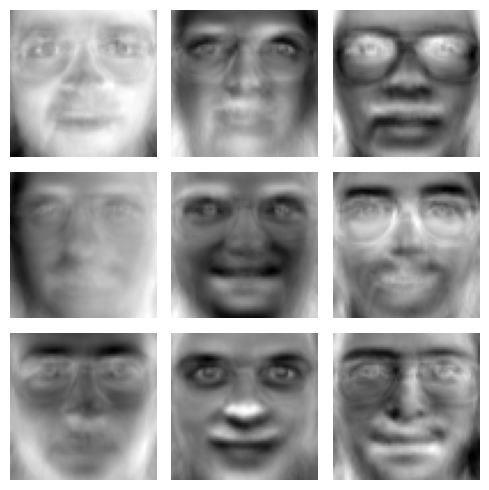

In [27]:
fig, axes = plt.subplots(3,3,figsize=(5,5))
for i in range(9):
  axes[i%3][i//3].imshow(eigenfaces[i].reshape(faceshape), cmap='gray')
  axes[i%3][i//3].axis('off')
plt.tight_layout()
plt.show()

С помощью $\mathbf W$ выполним проекцию $\mathbf X$ на пространство
меньшей размерности и найдем коэффициенты (веса) $\mathbf \Omega.$


In [28]:
weights = eigenfaces @ (X_train - mean).T
weights.shape

(66, 389)

### Распознавание лиц

Возьмем первое тестовое изображение. Напомню, это человек с id 38, другие
изображения которого есть в обучающей выборке (in-train-sample).

In [29]:
X_test[0].shape

(4096,)

In [30]:
in_sample_query = X_test[0].reshape(1,-1)
in_sample_query_weight = eigenfaces @ (in_sample_query - mean).T
euclidean_distance = np.linalg.norm(weights - in_sample_query_weight, axis=0)
in_sample_best_match = np.argmin(euclidean_distance)
print(in_sample_best_match)

385


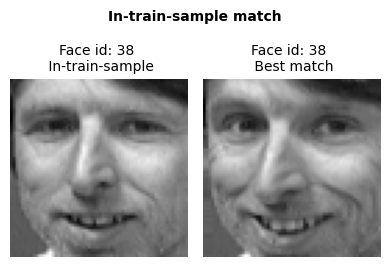

In [31]:
fig = plt.figure(figsize = (4,3))
fig.suptitle('In-train-sample match', size = 10, weight='bold')
ax1 = fig.add_subplot(121)
ax1.set_title(f'Face id: {y_test[0]} \n In-train-sample', {'fontsize' : 10})
ax1.imshow(images_test[0], cmap='gray')
ax1.axis('off')
ax2 = fig.add_subplot(122)
ax2.set_title(f'Face id: {y_train[in_sample_best_match]} \n Best match', {'fontsize' : 10})
ax2.imshow(images_train[in_sample_best_match], cmap='gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

Алгоритм отработал верно. Теперь попробуем найти в обучающей выборке
изображение лица человека, фотографий которого там нет (out-of-train-sample).

In [32]:
out_of_sample_query = X_test[1].reshape(1,-1)
out_of_sample_query_weight = eigenfaces @ (out_of_sample_query - mean).T
euclidean_distance = np.linalg.norm(weights - out_of_sample_query_weight, axis=0)
out_of_sample_best_match = np.argmin(euclidean_distance)
print(out_of_sample_best_match)

89


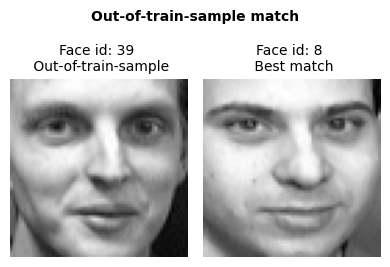

In [33]:
fig = plt.figure(figsize = (4,3))
fig.suptitle('Out-of-train-sample match', size = 10, weight='bold')
ax1 = fig.add_subplot(121)
ax1.set_title(f'Face id: {y_test[1]} \n Out-of-train-sample', {'fontsize' : 10})
ax1.imshow(images_test[1], cmap='gray')
ax1.axis('off')
ax2 = fig.add_subplot(122)
ax2.set_title(f'Face id: {y_train[out_of_sample_best_match]} \n Best match', {'fontsize' : 10})
ax2.imshow(images_train[out_of_sample_best_match], cmap='gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

Ожидаемо, найти фотографию этого человека в обучающей выборке не удалось.
Вместе с тем можно заметить определенное сходство предложенного алгоритмом
изображения с исходным.